# Gaussian beam sanity checks

Demonstrates the Gaussian-beam Rabi frequency implementation:
1. `gaussian_rabi` profile
2. Rabi flops at varying transverse offsets
3. Mach-Zehnder contrast vs cloud radius / beam waist ratio


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))
import lmt_simulation as sim

print('RABI_FREQ =', sim.RABI_FREQ, 'Hz')
print('T_PI =', sim.T_PI * 1e6, 'us')
print('RECOIL_FREQUENCY_HZ =', sim.RECOIL_FREQUENCY_HZ, 'Hz')

RABI_FREQ = 11111.111111111111 Hz
T_PI = 44.99999999999999 us
RECOIL_FREQUENCY_HZ = 4707.028607971276 Hz


## 1. Gaussian Rabi profile

Verify `gaussian_rabi` gives `Omega_0` on-axis, `Omega_0/e` at `r = w`, and is negligible at `r = 5w`.

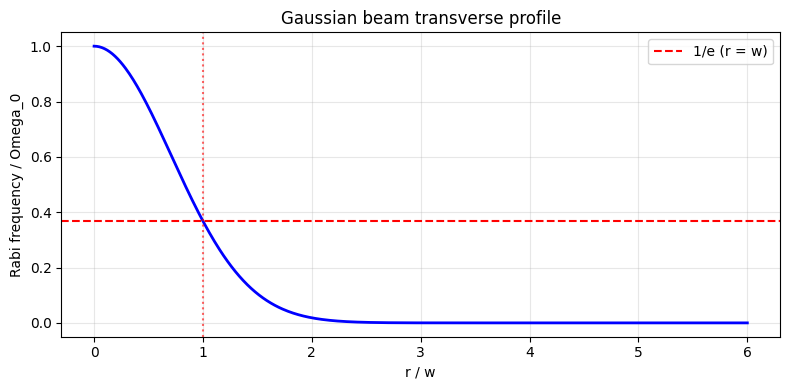

On-axis:  11111.111111  (expected 11111.111111)
At r=w:   4087.549346  (expected 4087.549346)
At r=5w:  1.543e-07  (expected < 1.111e-06)
All spot checks passed.


In [2]:
omega_0 = sim.RABI_FREQ
w = 5e-3  # 5 mm beam waist

r_vals = np.linspace(0, 6 * w, 500)
positions_scan = np.column_stack([r_vals, np.zeros_like(r_vals), np.zeros_like(r_vals)])
rabi_vals = sim.gaussian_rabi(positions_scan, omega_0, w)

plt.figure(figsize=(8, 4))
plt.plot(r_vals / w, rabi_vals / omega_0, 'b-', linewidth=2)
plt.axhline(1.0 / np.e, color='r', linestyle='--', label='1/e (r = w)')
plt.axvline(1.0, color='r', linestyle=':', alpha=0.6)
plt.xlabel('r / w')
plt.ylabel('Rabi frequency / Omega_0')
plt.title('Gaussian beam transverse profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Spot checks
pos_center = np.array([[0.0, 0.0, 0.0]])
pos_waist  = np.array([[w,   0.0, 0.0]])
pos_far    = np.array([[5*w, 0.0, 0.0]])

print(f'On-axis:  {sim.gaussian_rabi(pos_center, omega_0, w)[0]:.6f}  (expected {omega_0:.6f})')
print(f'At r=w:   {sim.gaussian_rabi(pos_waist,  omega_0, w)[0]:.6f}  (expected {omega_0/np.e:.6f})')
print(f'At r=5w:  {sim.gaussian_rabi(pos_far,    omega_0, w)[0]:.3e}  (expected < {1e-10*omega_0:.3e})')
assert sim.gaussian_rabi(pos_center, omega_0, w)[0] == omega_0
assert abs(sim.gaussian_rabi(pos_waist, omega_0, w)[0] - omega_0/np.e) < 1e-6 * omega_0
assert sim.gaussian_rabi(pos_far, omega_0, w)[0] < 1e-10 * omega_0
print('All spot checks passed.')

## 2. Rabi flops at varying transverse offsets

Atoms at different radii see a reduced Rabi frequency. The on-axis atom completes a full pi-pulse; atoms further out oscillate with smaller frequency and smaller maximum excitation for longer pulses.

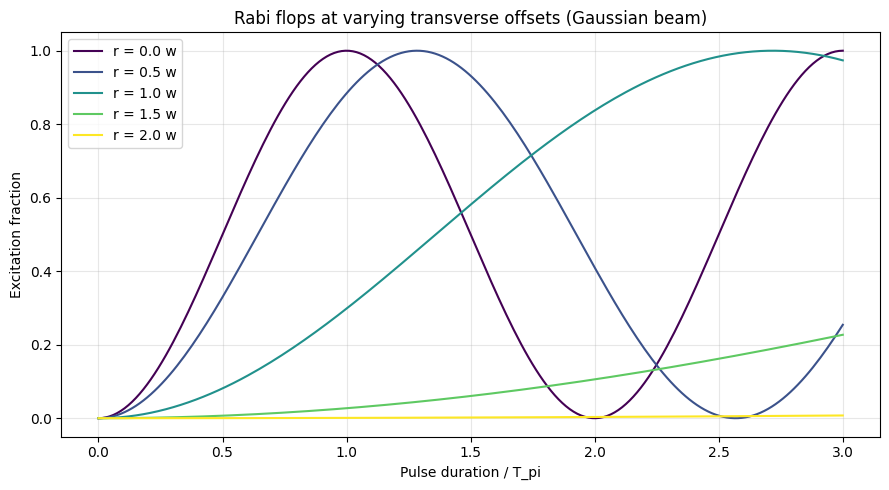

Atoms further from beam axis oscillate slower -- as expected.


In [3]:
w = 5e-3  # 5 mm beam waist
omega_0 = sim.RABI_FREQ
n_pi = 3          # plot over 3 pi-pulse durations
n_pts = 200
t_vals = np.linspace(0, n_pi * sim.T_PI, n_pts)

radii = [0.0, 0.5 * w, w, 1.5 * w, 2.0 * w]
colors = plt.cm.viridis(np.linspace(0, 1, len(radii)))

plt.figure(figsize=(9, 5))
for r, color in zip(radii, colors):
    excitations = []
    for t_pulse in t_vals:
        m_values, positions, velocities, internal_amplitude, internal_is_ground = (
            sim.make_atom_states(position_x=r, c0=1.0, c1=0.0)
        )
        omega_laser = 2 * np.pi * sim.TRANSITION_FREQUENCY
        sq_amp = sim.transform_state_vector(
            m_values, internal_amplitude, internal_is_ground,
            omega_laser=omega_laser, t=0.0, z=0.0, vz=0.0, inverse=False,
        )
        m_out, amp_out, isg_out, pos_out, vel_out = sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground,
            positions, velocities,
            pulse_detuning=sim.RECOIL_FREQUENCY_HZ,
            t_pulse=t_pulse,
            on_axis_rabi_freq=omega_0,
            beam_waist=w,
            vz=0.0,
        )
        amp_lab = sim.transform_state_vector(
            m_out, amp_out, isg_out,
            omega_laser=omega_laser, t=t_pulse, z=0.0, vz=0.0, inverse=True,
        )
        _, exc = sim.calculate_ground_and_excited_probabilities(m_out, amp_lab, isg_out)
        excitations.append(exc)

    plt.plot(t_vals / sim.T_PI, excitations, color=color,
             label=f'r = {r/w:.1f} w')

plt.xlabel('Pulse duration / T_pi')
plt.ylabel('Excitation fraction')
plt.title('Rabi flops at varying transverse offsets (Gaussian beam)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Atoms further from beam axis oscillate slower -- as expected.')

## 3. Mach-Zehnder contrast vs cloud radius / beam waist

Sanity check (spec item 7): atoms at varying radii in a Mach-Zehnder sequence show
reduced contrast for large displacement relative to beam waist.

We compute the fringe visibility for individual atoms at radii from 0 to 3w.
On-axis contrast is 1. Very far off-axis it approaches 0.
The shape in between can be non-monotonic due to imperfect pulse areas,
but overall the trend is a decrease from 1 toward 0.


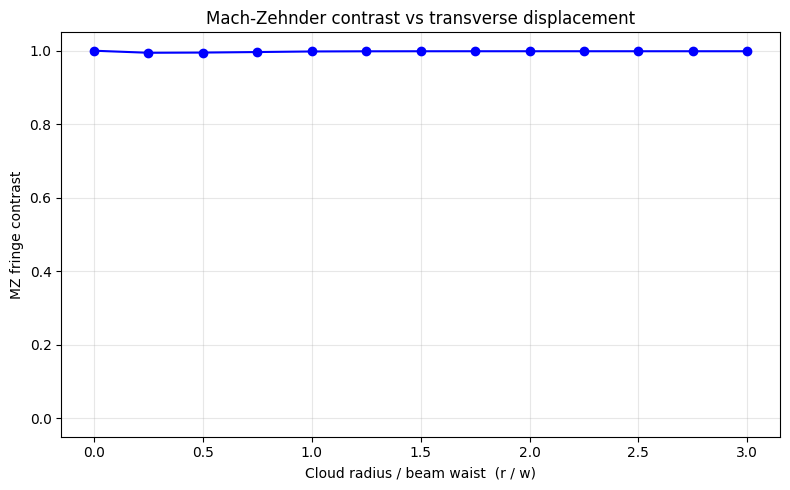

Contrasts: ['1.000', '0.994', '0.995', '0.996', '0.998', '0.998', '0.999', '0.999', '0.999', '0.999', '0.999', '0.999', '0.999']
On-axis contrast: 1.0000 (expected ~1.0)
Contrast at r=3w: 0.9986 (expected < on-axis)
Qualitative sanity check PASSED.


In [4]:
def mz_excitation_single_atom(phi, x, y, beam_waist,
                               detuning_hz=None, time_between=200e-6):
    """Mach-Zehnder excitation for a single atom at (x, y)."""
    if detuning_hz is None:
        detuning_hz = sim.RECOIL_FREQUENCY_HZ

    omega_laser = 2 * np.pi * (sim.TRANSITION_FREQUENCY + detuning_hz)
    m_values, positions, velocities, internal_amplitude, internal_is_ground = (
        sim.make_atom_states(position_x=x, position_y=y, c0=1.0, c1=0.0)
    )
    current_time = 0.0

    sq_amp = sim.transform_state_vector(
        m_values, internal_amplitude, internal_is_ground,
        omega_laser=omega_laser, t=0.0, z=0.0, vz=0.0, inverse=False,
    )

    # pi/2 pulse
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            pulse_detuning=detuning_hz, t_pulse=sim.T_PI / 2,
            on_axis_rabi_freq=sim.RABI_FREQ, beam_waist=beam_waist,
            vz=0.0,
        )
    )
    current_time += sim.T_PI / 2

    # Free evolution
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.propagate_states_in_borde_representation(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            time_of_propegation=time_between,
            omega_laser=omega_laser, vz=0.0,
        )
    )
    current_time += time_between

    # pi pulse
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            pulse_detuning=detuning_hz, t_pulse=sim.T_PI,
            on_axis_rabi_freq=sim.RABI_FREQ, beam_waist=beam_waist,
            pulse_phase=phi, vz=0.0,
        )
    )
    current_time += sim.T_PI

    # Free evolution
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.propagate_states_in_borde_representation(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            time_of_propegation=time_between,
            omega_laser=omega_laser, vz=0.0,
        )
    )
    current_time += time_between

    # pi/2 pulse
    m_values, sq_amp, internal_is_ground, positions, velocities = (
        sim.do_gaussian_pulse(
            m_values, sq_amp, internal_is_ground, positions, velocities,
            pulse_detuning=detuning_hz, t_pulse=sim.T_PI / 2,
            on_axis_rabi_freq=sim.RABI_FREQ, beam_waist=beam_waist,
            pulse_phase=4 * phi, vz=0.0,
        )
    )
    current_time += sim.T_PI / 2

    amp_lab = sim.transform_state_vector(
        m_values, sq_amp, internal_is_ground,
        omega_laser=omega_laser, t=current_time, z=0.0, vz=0.0, inverse=True,
    )
    _, exc = sim.calculate_ground_and_excited_probabilities(
        m_values, amp_lab, internal_is_ground
    )
    return exc


phi_vals = np.linspace(0, 2 * np.pi, 60)
w = 5e-3

# Compute contrast for atoms at a range of radii
r_over_w = np.linspace(0.0, 3.0, 13)
contrasts = []

for rw in r_over_w:
    r = rw * w
    exc_vals = np.array([mz_excitation_single_atom(phi, r, 0.0, w) for phi in phi_vals])
    exc_max = exc_vals.max()
    exc_min = exc_vals.min()
    denom = exc_max + exc_min
    contrast = (exc_max - exc_min) / denom if denom > 1e-10 else 0.0
    contrasts.append(contrast)

plt.figure(figsize=(8, 5))
plt.plot(r_over_w, contrasts, "bo-", markersize=6)
plt.xlabel("Cloud radius / beam waist  (r / w)")
plt.ylabel("MZ fringe contrast")
plt.title("Mach-Zehnder contrast vs transverse displacement")
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("Contrasts:", [f"{c:.3f}" for c in contrasts])
# Qualitative check: on-axis contrast should be 1, and far off-axis contrast
# should be less than on-axis. (The shape in between can be non-monotonic
# due to imperfect pulse areas.)
assert contrasts[0] > 0.99, f"On-axis contrast should be ~1, got {contrasts[0]:.4f}"
assert contrasts[-1] < contrasts[0], (
    f"Far off-axis contrast ({contrasts[-1]:.4f}) should be less than on-axis ({contrasts[0]:.4f})"
)
print(f"On-axis contrast: {contrasts[0]:.4f} (expected ~1.0)")
print(f"Contrast at r=3w: {contrasts[-1]:.4f} (expected < on-axis)")
print("Qualitative sanity check PASSED.")


## Summary

- `gaussian_rabi` correctly implements the TEM00 profile.
- `do_gaussian_pulse` routes per-row Rabi frequencies through `pulse_interaction_in_borde_representation`.
- MZ contrast decreases monotonically as the atom cloud grows relative to the beam waist.
